# 1. Linear advection: approximation, stability, monotonicity, convergence

The linear advection equation is the simplest hyperbolic equation, and almost everything that
matters for the finite-volume schemes of Piastra can already be seen on it. This notebook goes
through four ideas, each with a short piece of theory and a numerical experiment:

1. **Approximation** — what equation a scheme actually solves (truncation error, modified equation);
2. **Stability** — why the time step is limited (CFL condition, von Neumann analysis);
3. **Monotonicity** — why high-order schemes need limiters (Godunov's theorem, TVD schemes);
4. **Convergence** — how the error decreases with resolution, and what limits the rate.

The notebook lives in the `notebooks/` folder of the repository and imports Piastra from the folder
above. Every cell runs in seconds, the convergence studies in about a minute.

In [1]:
import os, sys, io, contextlib
sys.path.insert(0, os.path.abspath('..'))          # the Piastra root directory

import numpy as np
import matplotlib.pyplot as plt

from src.parameters import Parameters
from src.grid.grid_setup import Grid
from src.sim_state import SimState
from src.misc.helpers import initial_model
from main import SOLVER_DISPATCH


def setup(problem, N, **options):
    '''Parameters, grid, initial state and solver for a 1D advection problem of the catalogue.
    `options` are passed to Parameters: rec_type, RK_order, CFL, solver_type.'''
    with contextlib.redirect_stdout(io.StringIO()):        # silence the set-up messages
        par = Parameters(mode="adv", problem=problem, Nx1=N, Nx2=1, **options)
        grid = Grid(par.Nx1, par.Nx2, par.Ngc)
        state = SimState(grid, par)
        grid, state, par, eos = initial_model(grid, state, par)
        solver = SOLVER_DISPATCH["adv"](grid, state, eos, par)
    return grid, state, par, solver


def evolve(solver, par, t_end=None, max_steps=10**7):
    '''Advance the solution to t_end (default: the final time of the problem).'''
    if t_end is not None:
        par.timefin = t_end
    nsteps = 0
    while par.timenow < par.timefin - 1e-12 and nsteps < max_steps:
        state = solver.step_RK()
        nsteps += 1
    return state


def profile(grid, array):
    '''Cell centres and values along x1 (interior cells of a 1D run).'''
    g = grid.Ngc
    return grid.cx1[g:-g, g], array[g:-g, g].copy()

## 1. The equation and a finite-volume scheme

We solve

$$\frac{\partial u}{\partial t} + a\,\frac{\partial u}{\partial x} = 0, \qquad u(x,0) = u_0(x),$$

whose exact solution is a translation of the initial profile, $u(x,t) = u_0(x - at)$.
A finite-volume scheme evolves the **cell averages** $\bar u_i$ over cells of width $\Delta x$.
Integrating the equation over a cell and over one time step gives an exact relation,

$$\bar u_i^{\,n+1} = \bar u_i^{\,n} - \frac{\Delta t}{\Delta x}\left(F_{i+1/2} - F_{i-1/2}\right),$$

where $F_{i\pm1/2}$ is the time-averaged flux $a u$ through the cell faces. Everything a scheme does
is hidden in the approximation of these fluxes. The simplest choice for $a > 0$ takes the value from
the cell upwind of the face, $F_{i+1/2} = a\,\bar u_i$: the **upwind** (first-order Godunov) scheme.
Its behaviour is controlled by the Courant number

$$C = \frac{a\,\Delta t}{\Delta x},$$

the fraction of a cell that the profile moves in one step.

In Piastra this scheme is `rec_type='PCM'` (piecewise-constant values in each cell, so the face value
is the upwind cell average) with `RK_order='RK1'` (forward Euler in time); `CFL` sets $C$.
The problem `smooth1D` is a Gaussian of half-width $\delta = 0.1$ in the periodic domain $[0,1]$,
advected with $a = 1$ for one period, so the exact final solution equals the initial one.

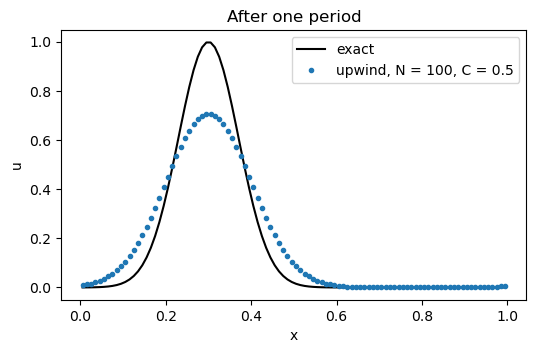

peak value: 0.706 (exact 1.000)


In [2]:
grid, state, par, solver = setup("smooth1D", 100, rec_type="PCM", RK_order="RK1", CFL=0.5)
x, u_exact = profile(grid, state.dens)          # after one period the exact solution is u0
state = evolve(solver, par)
x, u = profile(grid, state.dens)

plt.figure(figsize=(6, 3.5))
plt.plot(x, u_exact, 'k-', label='exact')
plt.plot(x, u, 'o', ms=3, label='upwind, N = 100, C = 0.5')
plt.xlabel('x'); plt.ylabel('u'); plt.legend(); plt.title('After one period')
plt.show()
print(f"peak value: {u.max():.3f} (exact 1.000)")

The profile has moved correctly but has been strongly smeared: after 200 time steps the peak has
lost a third of its height. To understand why, we need to know which equation the scheme really solves.

## 2. Approximation: the modified equation

Replace the discrete values in the scheme by a smooth function and expand in Taylor series around
$(x_i, t^n)$. For the upwind scheme with forward Euler this gives

$$\frac{\partial u}{\partial t} + a\,\frac{\partial u}{\partial x}
  = D_{\rm num}\,\frac{\partial^2 u}{\partial x^2} + O(\Delta x^2),
  \qquad D_{\rm num} = \frac{a\,\Delta x}{2}\,(1 - C).$$

Two conclusions follow. The scheme is **consistent**: the extra term vanishes as $\Delta x \to 0$,
and the leading error is $O(\Delta x)$, so the scheme is **first order**. And, more usefully, the
error has a physical meaning: to leading order the scheme solves an advection-*diffusion* equation
with a numerical diffusivity $D_{\rm num}$. This is the **modified equation** of the scheme.

We can check it quantitatively. Under diffusion with coefficient $D$ a Gaussian stays Gaussian,

$$u(x,t) = \frac{\delta}{\sqrt{\delta^2 + 4Dt}}\,
  \exp\left[-\frac{(x - x_0 - at)^2}{\delta^2 + 4Dt}\right],$$

so the modified equation predicts both the height and the width of the smeared profile.

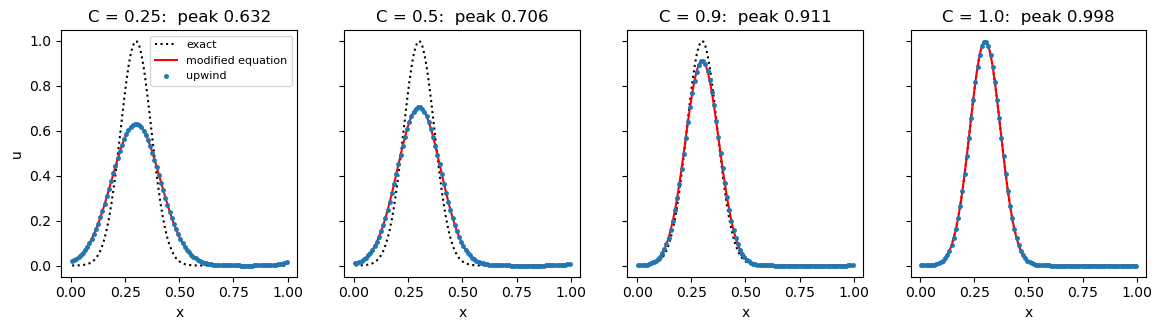

In [3]:
def gaussian_after_diffusion(x, t, D, x0=0.3, delta=0.1, a=1.0, L=1.0):
    '''Periodic Gaussian (the smooth1D profile) advected with speed a and diffused with coefficient D.'''
    w2 = delta**2 + 4.0 * D * t
    xc = (x0 + a * t) % L
    return sum(delta / np.sqrt(w2) * np.exp(-(x - xc - k * L)**2 / w2) for k in (-1, 0, 1))

N = 100
dx = 1.0 / N
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), sharey=True)
for ax, C in zip(axes, [0.25, 0.5, 0.9, 1.0]):
    grid, state, par, solver = setup("smooth1D", N, rec_type="PCM", RK_order="RK1", CFL=C)
    state = evolve(solver, par)
    x, u = profile(grid, state.dens)
    D = 0.5 * dx * (1.0 - C)
    ax.plot(x, gaussian_after_diffusion(x, 0.0, 0.0), 'k:', label='exact')
    ax.plot(x, gaussian_after_diffusion(x, 1.0, D), 'r-', label='modified equation')
    ax.plot(x, u, 'o', ms=2.5, label='upwind')
    ax.set_title(f'C = {C}:  peak {u.max():.3f}')
    ax.set_xlabel('x')
axes[0].set_ylabel('u'); axes[0].legend(fontsize=8)
plt.show()

The modified equation predicts the smeared profiles almost exactly. Note the last panel: at
$C = 1$ the numerical diffusion vanishes and the upwind scheme reproduces the exact solution to
round-off. The characteristic traced back from a cell centre over one time step then lands exactly
on the centre of the upwind cell. This is a special property of linear advection with constant
speed on a uniform grid; it has no analogue for nonlinear systems, where the wave speeds vary in space.

## 3. Stability

A consistent scheme is not necessarily useful. Take a single Fourier mode,
$\bar u_i^{\,n} = G^n e^{i k x_i}$, and substitute it into the scheme (**von Neumann analysis**).
For the upwind scheme with forward Euler the amplification factor per step is

$$G(\theta) = 1 - C\,(1 - e^{-i\theta}), \qquad
  |G|^2 = 1 - 2C(1 - C)(1 - \cos\theta), \qquad \theta = k\,\Delta x .$$

All modes are damped, $|G| \le 1$, if and only if $0 \le C \le 1$: this is the
**Courant–Friedrichs–Lewy (CFL) condition**. Its physical meaning is that the numerical domain of
dependence (one cell per step) must contain the physical one ($a\,\Delta t$). The centred flux
$F_{i+1/2} = a(\bar u_i + \bar u_{i+1})/2$ with forward Euler looks more accurate but gives
$G = 1 - iC\sin\theta$ with $|G| > 1$ for every $C > 0$: it is **unconditionally unstable**.

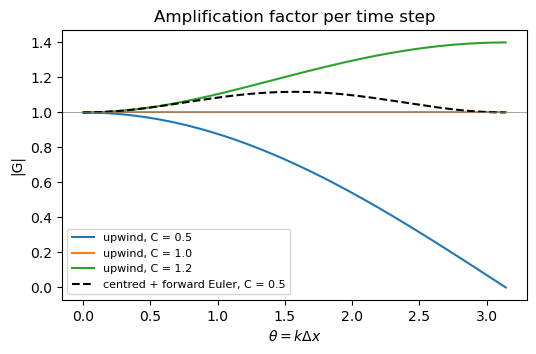

In [4]:
theta = np.linspace(0, np.pi, 200)
plt.figure(figsize=(6, 3.5))
for C in [0.5, 1.0, 1.2]:
    G = 1.0 - C * (1.0 - np.exp(-1j * theta))
    plt.plot(theta, np.abs(G), label=f'upwind, C = {C}')
plt.plot(theta, np.abs(1.0 - 0.5j * np.sin(theta)), 'k--', label='centred + forward Euler, C = 0.5')
plt.axhline(1.0, color='gray', lw=0.5)
plt.xlabel(r'$\theta = k\Delta x$'); plt.ylabel('|G|'); plt.legend(fontsize=8)
plt.title('Amplification factor per time step')
plt.show()

In a simulation the unstable modes are seeded by round-off errors and grow exponentially. For
$C = 1.1$ the shortest wave, $\theta = \pi$, is amplified by $|1 - 2C| = 1.2$ per step.
We follow the maximum of $|u|$ over several periods:

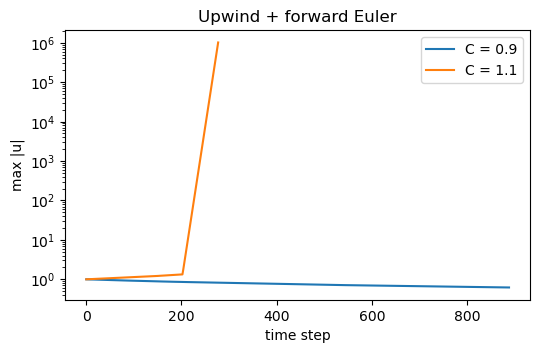

In [5]:
plt.figure(figsize=(6, 3.5))
for C in [0.9, 1.1]:
    grid, state, par, solver = setup("smooth1D", 100, rec_type="PCM", RK_order="RK1", CFL=C)
    par.timefin = 8.0
    umax = []
    while par.timenow < par.timefin - 1e-12:
        state = solver.step_RK()
        umax.append(np.abs(profile(grid, state.dens)[1]).max())
        if umax[-1] > 1e6:
            break
    plt.semilogy(umax, label=f'C = {C}')
plt.xlabel('time step'); plt.ylabel('max |u|'); plt.legend()
plt.title('Upwind + forward Euler')
plt.show()

With $C = 1.1$ nothing is visible for about two hundred steps: the round-off seed, of order
$10^{-16}$, has to grow by sixteen orders of magnitude first ($1.2^{200} \approx 10^{16}$).
Then the solution is destroyed within a few dozen steps. An instability that appears "suddenly"
after a long quiet phase is typical, and it is a good reason never to trust a short test run.

Stability is a property of the **combination** of the spatial operator and the time integrator.
To see this, we use a piecewise-linear reconstruction with an unlimited, centred slope. It is
second-order accurate in space, but together with forward Euler it is unstable; with the two-stage
Runge–Kutta method (RK2) it is stable.

The PLM limiter is not a run-time parameter of Piastra (van Leer is used by default), so for the
experiments below we swap the reconstruction function used by the advection module with a small
helper:

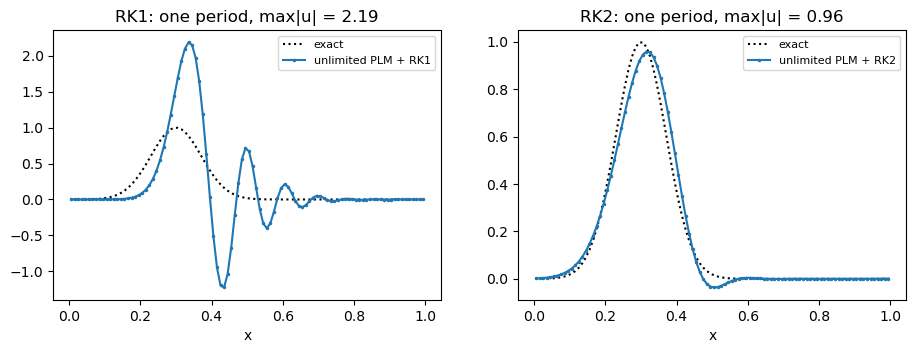

In [6]:
import src.models.adv.adv_step as adv_step
from src.common.high_order_rec import VarReconstruct as _VarReconstruct

def use_limiter(limiter):
    '''Select the PLM slope limiter of the advection solver:
    'VL' (van Leer, the default), 'MM' (minmod), 'MC' (monotonized central),
    'KOR' (Koren), or 'NO' (unlimited centred slope).'''
    adv_step.VarReconstruct = lambda var, g, rec, dim: _VarReconstruct(var, g, rec, dim, limiter_type=limiter)

use_limiter('NO')
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, rk in zip(axes, ['RK1', 'RK2']):
    grid, state, par, solver = setup("smooth1D", 100, rec_type="PLM", RK_order=rk, CFL=0.5)
    x, u0 = profile(grid, state.dens)
    state = evolve(solver, par, t_end=1.0)
    x, u = profile(grid, state.dens)
    ax.plot(x, u0, 'k:', label='exact')
    ax.plot(x, u, '.-', ms=3, label=f'unlimited PLM + {rk}')
    ax.set_title(f'{rk}: one period, max|u| = {np.abs(u).max():.2f}')
    ax.set_xlabel('x'); ax.legend(fontsize=8)
plt.show()
use_limiter('VL')                                   # back to the default

With forward Euler the perturbation grows and distorts the whole pulse (the growth continues if
the run is extended); with RK2 the scheme is stable. Note, however, the undershoot behind the pulse in the stable run: an
unlimited second-order scheme is not monotone. This is the subject of the next section.

## 4. Monotonicity

The **Lax–Wendroff** scheme (`solver_type='LW'`) is second order in space and time. On a smooth
profile it is far more accurate than upwind. On a discontinuity, however, it produces oscillations,
and this is not a defect of this particular scheme. **Godunov's theorem** states that a *linear*
scheme that does not create new extrema (a monotone scheme) is at most first-order accurate.
High order and monotonicity can coexist only in **nonlinear** schemes, whose coefficients depend on
the solution itself.

The practical form of this idea is a **slope limiter**. The piecewise-linear reconstruction uses in
cell $i$ the slope $\phi(r_i)\,(\bar u_i - \bar u_{i-1})$, where
$r_i = (\bar u_{i+1} - \bar u_i)/(\bar u_i - \bar u_{i-1})$ measures the smoothness of the solution.
The scheme is **total variation diminishing** (TVD), i.e. $\sum_i |\bar u_{i+1} - \bar u_i|$ does not
grow, if $\phi$ lies in the region $0 \le \phi \le \min(2r, 2)$ (Sweby, 1984). Second-order accuracy
additionally requires $\phi(1) = 1$. Piastra implements four classic limiters:

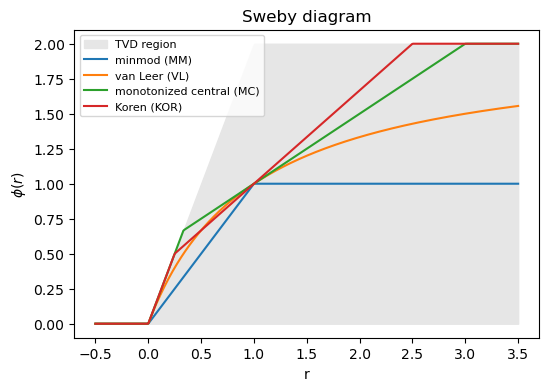

In [7]:
r = np.linspace(-0.5, 3.5, 400)
limiters = {
    'minmod (MM)':              np.maximum(0, np.minimum(1, r)),
    'van Leer (VL)':            (r + np.abs(r)) / (1 + np.abs(r)),
    'monotonized central (MC)': np.maximum(0, np.minimum.reduce([2 * r, 0.5 * (1 + r), 2 + 0 * r])),
    'Koren (KOR)':              np.maximum(0, np.minimum.reduce([2 * r, (1 + 2 * r) / 3, 2 + 0 * r])),
}
plt.figure(figsize=(6, 4))
plt.fill_between(r, 0, np.clip(np.minimum(2 * r, 2), 0, None), color='0.9', label='TVD region')
for name, phi in limiters.items():
    plt.plot(r, phi, label=name)
plt.xlabel('r'); plt.ylabel(r'$\phi(r)$'); plt.legend(fontsize=8); plt.title('Sweby diagram')
plt.show()

Now the top-hat profile `disc1D` (values 1 and 2) after one period, with $N = 200$:

scheme             max u   min u     TV   (exact: 2, 1, 2)
upwind (PCM)       1.954   1.000  1.909
Lax-Wendroff       2.232   0.769  3.847
PLM + minmod       1.998   1.000  1.996
PLM + van Leer     2.000   1.000  2.000
PLM + MC           2.000   1.000  2.000


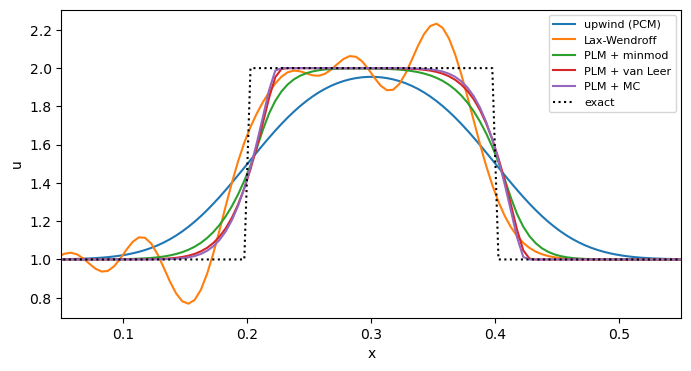

In [8]:
def total_variation(u):
    return np.sum(np.abs(np.diff(np.append(u, u[0]))))

runs = [('upwind (PCM)',   dict(rec_type='PCM', RK_order='RK1'), 'VL'),
        ('Lax-Wendroff',   dict(solver_type='LW'),                'VL'),
        ('PLM + minmod',   dict(rec_type='PLM', RK_order='RK2'), 'MM'),
        ('PLM + van Leer', dict(rec_type='PLM', RK_order='RK2'), 'VL'),
        ('PLM + MC',       dict(rec_type='PLM', RK_order='RK2'), 'MC')]

plt.figure(figsize=(8, 4))
print(f"{'scheme':16s} {'max u':>7s} {'min u':>7s} {'TV':>6s}   (exact: 2, 1, 2)")
for name, opts, lim in runs:
    use_limiter(lim)
    grid, state, par, solver = setup("disc1D", 200, CFL=0.5, **opts)
    if name == 'upwind (PCM)':
        x, u0 = profile(grid, state.dens)
    state = evolve(solver, par)
    x, u = profile(grid, state.dens)
    plt.plot(x, u, label=name)
    print(f"{name:16s} {u.max():7.3f} {u.min():7.3f} {total_variation(u):6.3f}")
use_limiter('VL')
plt.plot(x, u0, 'k:', label='exact')
plt.xlim(0.05, 0.55); plt.xlabel('x'); plt.ylabel('u'); plt.legend(fontsize=8)
plt.show()

Lax–Wendroff overshoots and undershoots and increases the total variation; the TVD schemes do not
create new extrema. Among them minmod is the most diffusive and MC the sharpest, as the Sweby
diagram suggests: the larger $\phi$, the steeper the reconstructed profile.

The price of the TVD property is paid at **smooth extrema**. At a maximum $r < 0$, so every TVD
limiter sets the slope to zero there and the scheme locally drops to first order: the peaks are
clipped. Higher-order reconstructions (PPM, MP5, WENO) are designed to recognise smooth extrema and
to keep them:

In [9]:
print(f"{'reconstruction':16s} peak after one period (exact 1.000), N = 100, RK3, C = 0.4")
for name, rec, lim in [('PLM + minmod', 'PLM', 'MM'), ('PLM + van Leer', 'PLM', 'VL'),
                       ('PLM + MC', 'PLM', 'MC'), ('PPM', 'PPM', 'VL'),
                       ('WENO', 'WENO', 'VL'), ('MP5', 'MP5', 'VL')]:
    use_limiter(lim)
    grid, state, par, solver = setup("smooth1D", 100, rec_type=rec, RK_order='RK3', CFL=0.4)
    state = evolve(solver, par)
    print(f"{name:16s} {profile(grid, state.dens)[1].max():.4f}")
use_limiter('VL')

reconstruction   peak after one period (exact 1.000), N = 100, RK3, C = 0.4
PLM + minmod     0.8630
PLM + van Leer   0.9324
PLM + MC         0.9580
PPM              0.9767
WENO             0.9884
MP5              0.9970


## 5. Convergence

A scheme **converges** if the numerical solution approaches the exact one as the grid is refined.
We measure the error in the $L_1$ norm, $\epsilon = \Delta x \sum_i |\bar u_i - u(x_i)|$, and the
observed order between two resolutions as $p = \log_2[\epsilon(N)/\epsilon(2N)]$.

For linear problems the **Lax equivalence theorem** states that a consistent scheme converges if and
only if it is stable, and the order of convergence equals the order of the truncation error. For
limited (nonlinear) schemes there is no such theorem, but in practice the same picture holds on
smooth solutions — with the caveat of extremum clipping. We run the Gaussian over one period with
every reconstruction of Piastra and the third-order Runge–Kutta method.

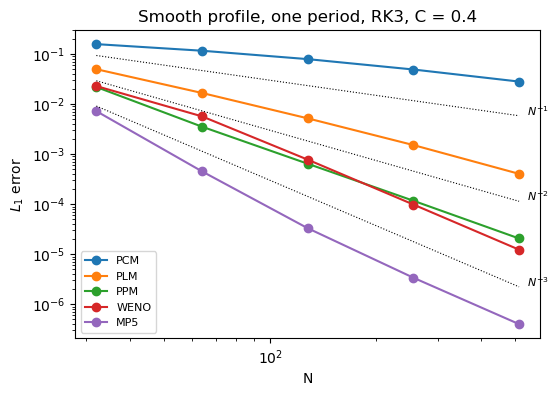

observed orders between successive resolutions:
  PCM    0.44   0.56   0.69   0.80
  PLM    1.58   1.68   1.77   1.91
  PPM    2.63   2.46   2.46   2.50
  WENO   2.01   2.87   2.98   3.00
  MP5    4.00   3.77   3.29   3.08


In [11]:
Ns = [32, 64, 128, 256, 512]
recs = ['PCM', 'PLM', 'PPM', 'WENO', 'MP5']
errors = {}
for rec in recs:
    errors[rec] = []
    for N in Ns:
        grid, state, par, solver = setup("smooth1D", N, rec_type=rec, RK_order='RK3', CFL=0.4)
        x, u0 = profile(grid, state.dens)
        state = evolve(solver, par)
        errors[rec].append(np.sum(np.abs(profile(grid, state.dens)[1] - u0)) / N)

plt.figure(figsize=(6, 4))
for rec in recs:
    plt.loglog(Ns, errors[rec], 'o-', label=rec)
Ns_ = np.array(Ns, dtype=float)
for p, c in [(1, 3.0), (2, 30.0), (3, 300.0)]:
    plt.loglog(Ns_, c * Ns_**(-p), 'k:', lw=0.8)
    plt.text(Ns_[-1] * 1.05, c * Ns_[-1]**(-p), f'$N^{{-{p}}}$', fontsize=8)
plt.xlabel('N'); plt.ylabel(r'$L_1$ error'); plt.legend(fontsize=8)
plt.title('Smooth profile, one period, RK3, C = 0.4')
plt.show()

print('observed orders between successive resolutions:')
for rec in recs:
    e = errors[rec]
    print(f"  {rec:5s}", "  ".join(f"{np.log2(e[i] / e[i + 1]):5.2f}" for i in range(len(e) - 1)))

Three things are worth noticing.

* PCM approaches first order only slowly (0.4 → 0.8 over this range). The modified equation
  explains why: at coarse resolution the numerical diffusion smears the Gaussian almost completely,
  the error is of the order of the amplitude itself, and the asymptotic regime, in which the error
  is a small correction proportional to $\Delta x$, starts only at several hundred cells.
* PLM approaches second order (1.6 → 1.9). The limiter keeps it slightly below 2 because the
  extremum is clipped in a region whose width shrinks with the grid.
* The high-order reconstructions have much smaller errors, but at fixed Courant number the time
  step shrinks with the cell size, so the third-order time integrator adds an error $\propto \Delta t^3
  \propto \Delta x^3$: WENO and MP5 settle at the order of the time integrator, three, however
  accurate the reconstruction is in space. PPM stays near 2.5 because its own limiter still
  flattens the extremum.
* The coarsest resolutions are **pre-asymptotic**: with 32 cells the Gaussian of half-width 0.1 is
  resolved by about six cells, and the observed orders there are not yet meaningful.

For a **discontinuous** solution the picture changes completely: the error is concentrated in the
smeared region around the jumps, and its width decreases more slowly than $\Delta x$. For a
first-order scheme the smearing is diffusive, of width $\sim\sqrt{D_{\rm num} t} \propto \Delta x^{1/2}$,
so the $L_1$ error decreases only as $N^{-1/2}$; for second-order schemes the rate is about $N^{-2/3}$,
and even the fifth-order MP5 stays below first order.

In [12]:
print('top-hat profile, L1 errors and orders (RK3, C = 0.4)')
for rec in ['PCM', 'PLM', 'MP5']:
    e = []
    for N in [64, 128, 256, 512]:
        grid, state, par, solver = setup("disc1D", N, rec_type=rec, RK_order='RK3', CFL=0.4)
        x, u0 = profile(grid, state.dens)
        state = evolve(solver, par)
        e.append(np.sum(np.abs(profile(grid, state.dens)[1] - u0)) / N)
    print(f"  {rec:4s} errors", "  ".join(f"{v:.2e}" for v in e),
          "  orders", "  ".join(f"{np.log2(e[i] / e[i + 1]):.2f}" for i in range(3)))

top-hat profile, L1 errors and orders (RK3, C = 0.4)
  PCM  errors 1.88e-01  1.39e-01  9.97e-02  7.05e-02   orders 0.44  0.48  0.50
  PLM  errors 5.93e-02  3.64e-02  2.23e-02  1.38e-02   orders 0.71  0.70  0.70
  MP5  errors 3.18e-02  1.80e-02  1.02e-02  5.82e-03   orders 0.82  0.82  0.82


Finally, the **time integrator** has its own order. To measure it, we keep the grid fixed and refine
only the time step, comparing with a reference solution computed on the same grid with a very small
time step: the spatial error is then the same in all runs and cancels. With the piecewise-constant
reconstruction the semi-discrete operator is linear and smooth, and the Runge–Kutta methods show their
design orders cleanly:

In [13]:
N, t_end = 128, 0.25
def final_state(rk, C):
    grid, state, par, solver = setup("smooth1D", N, rec_type='PCM', RK_order=rk, CFL=C)
    return profile(grid, evolve(solver, par, t_end=t_end).dens)[1]

for rk in ['RK1', 'RK2', 'RK3']:
    reference = final_state(rk, 0.0125)
    e = [np.sum(np.abs(final_state(rk, C) - reference)) / N for C in [0.8, 0.4, 0.2, 0.1]]
    print(f"{rk}: temporal orders", "  ".join(f"{np.log2(e[i] / e[i + 1]):.2f}" for i in range(3)))

RK1: temporal orders 1.12  1.09  1.12
RK2: temporal orders 2.01  2.01  2.02
RK3: temporal orders 3.00  3.00  3.00


## Summary

* A scheme approximates a *modified* equation; for upwind the leading error is a numerical
  diffusion $D_{\rm num} = a\Delta x(1-C)/2$, which predicts the smearing quantitatively.
* Stability limits the time step (CFL condition) and depends on the combination of the spatial
  operator and the time integrator.
* Linear schemes of more than first order cannot be monotone (Godunov); limiters give nonlinear
  TVD schemes that are second order away from extrema and monotone at discontinuities.
* Observed convergence rates depend on the smoothness of the solution, on the resolution of the
  features (pre-asymptotic regime), and on the time integrator, not only on the reconstruction.

## Exercises

1. Repeat the modified-equation experiment for the Lax–Wendroff scheme. Its leading error is
   *dispersive*, $\propto u_{xxx}$: what does that do to the Gaussian?
2. Show analytically that the Lax–Wendroff scheme is also exact at $C = 1$, and check it numerically.
3. Add the *superbee* limiter, $\phi(r) = \max[0, \min(2r, 1), \min(r, 2)]$, to `rec_PLM` in
   `src/common/high_order_rec.py`. Where does it lie in the Sweby diagram? Compare it with MC on the
   top-hat and on the Gaussian: what happens to smooth profiles?
4. Find the largest stable Courant number of PLM + RK2 and of PPM + RK3.
5. Run the two-dimensional problem `smooth2D` and measure the convergence order of PPM and MP5.
   Why is it close to two? (The answer is in the notebook on two-dimensional gas dynamics.)